In [ ]:
import os
import random
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

from google.colab import drive
drive.mount('/content/drive')
!ls /content/drive/MyDrive/Datasets/isic
!ls /content/drive/MyDrive/Datasets/pets
!ls /content/drive/MyDrive/Datasets/crack
#!ls /content/drive/MyDrive/Datasets/deepglobe

!cp -r /content/drive/MyDrive/Datasets/isic /content/
!cp -r /content/drive/MyDrive/Datasets/pets /content/
!cp -r /content/drive/MyDrive/Datasets/crack /content/
#!cp -r /content/drive/MyDrive/Datasets/deepglobe /content/


#Lien des datasets
#isic :  https://drive.google.com/drive/folders/12C3NGXHc-IeUkqeUGTCgweLiPeXsbeJ4?usp=drive_link
#pets :  https://drive.google.com/drive/folders/1HeZ1gOUrNPCYfOQMr72PIPAQ4PJBqPF2?usp=drive_link
#deepglobe : https://drive.google.com/drive/folders/1655iV3RwGmN0ftzRC6QjQG4eLXdTHO-A?usp=drive_link
#crack : https://drive.google.com/drive/folders/1nvZqrrwwzV0O_-EwofQgSB7qo2GCguBg?usp=drive_link

Device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
test  train
test  train
test  train


In [ ]:
########################################
# SEED GLOBAL — REPRODUCTIBILITÉ
########################################

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

########################################
# CONFIGURATION
########################################

# dataset à utiliser : "isic" | "pets" | "deepglobe" | "crack"
DATASET = "isic"

# augmentation : "baseline" | "flip" | "flip_rotation" | "full_aug" | "geo_strong" | "extreme_aug"
AUGMENTATION_CONFIG = "baseline"

# fraction du train set à utiliser (float 0-1 ou int)
TRAIN_SIZE = 0.1

# early stopping
PATIENCE = 5

In [ ]:
class ISICDataset(Dataset):
    def __init__(self, images_dir, masks_dir, image_transform=None, mask_transform=None, augmentation_config="baseline"):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_transform = image_transform
        self.mask_transform = mask_transform
        self.augmentation_config = augmentation_config

        self.images = sorted(os.listdir(images_dir))
        self.masks = sorted(os.listdir(masks_dir))
        assert len(self.images) == len(self.masks), "Images et masques doivent correspondre !"

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.images[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        # CORRECTION : seed aléatoire (pas déterministe par index)
        # → les augmentations varient à chaque epoch
        seed = random.randint(0, 2**32 - 1)

        if self.image_transform:
            random.seed(seed)
            torch.manual_seed(seed)
            image = self.image_transform(image)

        if self.mask_transform:
            random.seed(seed)
            torch.manual_seed(seed)
            mask = self.mask_transform(mask)

        mask = (mask > 0).float()
        return image, mask


class OxfordPetDataset(Dataset):
    """
    CORRECTION : les augmentations utilisent maintenant image_transform / mask_transform
    passés en paramètre, comme les deux autres datasets. Plus de dépendance à la
    variable globale AUGMENTATION_CONFIG.
    """
    def __init__(self, images_dir, masks_dir, image_transform=None, mask_transform=None, augmentation_config="baseline"):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_transform = image_transform
        self.mask_transform = mask_transform
        self.augmentation_config = augmentation_config

        self.images = []
        self.masks = []

        for img in sorted(os.listdir(images_dir)):
            mask_name = img.replace(".jpg", ".png")
            mask_path = os.path.join(masks_dir, mask_name)
            if os.path.exists(mask_path):
                self.images.append(img)
                self.masks.append(mask_name)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.images[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        # Binarisation
        mask_np = np.array(mask)
        mask_np = (mask_np == 1).astype(np.uint8) * 255
        mask = Image.fromarray(mask_np)

        # Resize de base
        image = transforms.Resize((256, 256))(image)
        mask = transforms.Resize((256, 256), interpolation=InterpolationMode.NEAREST)(mask)

        aug = self.augmentation_config

        ########################################
        # AUGMENTATIONS SYNCHRONISÉES
        ########################################

        if aug in ["flip", "flip_rotation", "full_aug", "geo_strong", "extreme_aug"]:
            if random.random() < 0.5:
                image = transforms.functional.hflip(image)
                mask = transforms.functional.hflip(mask)

        if aug in ["full_aug", "geo_strong", "extreme_aug"]:
            if random.random() < 0.5:
                image = transforms.functional.vflip(image)
                mask = transforms.functional.vflip(mask)

        if aug in ["flip_rotation", "full_aug", "geo_strong", "extreme_aug"]:
            angle = random.uniform(-25, 25)
            image = transforms.functional.rotate(image, angle)
            mask = transforms.functional.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)

        if aug in ["geo_strong", "extreme_aug"]:
            tx = random.uniform(-0.1, 0.1) * 256
            ty = random.uniform(-0.1, 0.1) * 256
            scale = random.uniform(0.8, 1.2)
            shear = random.uniform(-10, 10)

            image = transforms.functional.affine(image, angle=0, translate=(tx, ty), scale=scale, shear=shear)
            mask = transforms.functional.affine(mask, angle=0, translate=(tx, ty), scale=scale, shear=shear,
                                                interpolation=InterpolationMode.NEAREST)

        ########################################
        # IMAGE ONLY AUGMENTATIONS
        ########################################

        if aug in ["full_aug", "extreme_aug"]:
            image = transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)(image)

        if aug == "extreme_aug":
            image = transforms.GaussianBlur(kernel_size=3)(image)

        ########################################
        # TENSORS
        ########################################

        image = transforms.ToTensor()(image)
        image = transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])(image)

        mask = transforms.ToTensor()(mask)
        mask = (mask > 0.5).float()

        return image, mask


class CrackDataset(Dataset):
    def __init__(self, images_dir, masks_dir, image_transform=None, mask_transform=None, augmentation_config="baseline"):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_transform = image_transform
        self.mask_transform = mask_transform
        self.augmentation_config = augmentation_config

        self.images = sorted(os.listdir(images_dir))
        self.masks = sorted(os.listdir(masks_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.images[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # ← niveaux de gris, pas RGB

        seed = random.randint(0, 2**32 - 1)

        if self.image_transform:
            random.seed(seed)
            torch.manual_seed(seed)
            image = self.image_transform(image)

        if self.mask_transform:
            random.seed(seed)
            torch.manual_seed(seed)
            mask = self.mask_transform(mask)  # shape: [1, H, W], valeurs [0, 1]

        mask = (mask > 0.5).float()  # ← binarisation simple, plus de logique RGB

        return image, mask

In [ ]:
########################################
# TRANSFORMS
########################################

def build_image_transform(augmentation_config):
    if augmentation_config == "baseline":
        return transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])

    elif augmentation_config == "flip":
        return transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])

    elif augmentation_config == "flip_rotation":
        return transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(20),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])

    elif augmentation_config == "full_aug":
        return transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(25),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])

    elif augmentation_config == "geo_strong":
        return transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(30),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=10),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])

    elif augmentation_config == "extreme_aug":
        return transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(35),
            transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.7, 1.3), shear=15),
            transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.15),
            transforms.GaussianBlur(kernel_size=3),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])

    else:
        raise ValueError(f"Unknown augmentation config: {augmentation_config}")


base_image_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

base_mask_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=InterpolationMode.NEAREST),
    transforms.ToTensor()
])

image_transform = build_image_transform(AUGMENTATION_CONFIG)
mask_transform = base_mask_transform  # le mask ne reçoit pas de ColorJitter etc.

print("Using augmentation:", AUGMENTATION_CONFIG)

Using augmentation: baseline


In [ ]:
########################################
# DATASET SELECTION
########################################

DATASET_CLASSES = {
    "isic": ISICDataset,
    "pets": OxfordPetDataset,
    "crack": CrackDataset,
    #"deepglobe": DeepGlobeDataset,
}

DATASET_PATHS = {
    "isic": {
        "train_images": "/content/isic/train/images",
        "train_masks": "/content/isic/train/masks",
        "test_images": "/content/isic/test/images",
        "test_masks": "/content/isic/test/masks",
    },
    "pets": {
        "train_images": "/content/pets/train/images",
        "train_masks": "/content/pets/train/masks",
        "test_images": "/content/pets/test/images",
        "test_masks": "/content/pets/test/masks",
    },
    "deepglobe": {
        "train_images": "/content/deepglobe/train/images",
        "train_masks": "/content/deepglobe/train/masks",
        "test_images": "/content/deepglobe/test/images",
        "test_masks": "/content/deepglobe/test/masks",
    },
    "crack": {
        "train_images": "/content/crack/train/images",
        "train_masks": "/content/crack/train/masks",
        "test_images": "/content/crack/test/images",
        "test_masks": "/content/crack/test/masks",
    },
}

if DATASET not in DATASET_CLASSES:
    raise ValueError(f"Unknown dataset: {DATASET}")

DatasetClass = DATASET_CLASSES[DATASET]
paths = DATASET_PATHS[DATASET]

print("Dataset:", DATASET)

Dataset: isic


In [ ]:
from torch.utils.data import ConcatDataset

# Charger train + test dans un seul pool
full_dataset_train = DatasetClass(
    paths["train_images"], paths["train_masks"],
    image_transform=image_transform,
    mask_transform=mask_transform,
    augmentation_config=AUGMENTATION_CONFIG,
)
full_dataset_test = DatasetClass(
    paths["test_images"], paths["test_masks"],
    image_transform=image_transform,
    mask_transform=mask_transform,
    augmentation_config=AUGMENTATION_CONFIG,
)

full_dataset = ConcatDataset([full_dataset_train, full_dataset_test])

# Limiter si besoin
total = len(full_dataset)
if isinstance(TRAIN_SIZE, float):
    subset_size = int(TRAIN_SIZE * total)
else:
    subset_size = min(TRAIN_SIZE, total)

full_dataset = Subset(full_dataset, range(subset_size))

# Redistribuer 70% train / 15% val / 15% test
total = len(full_dataset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

train_dataset, val_dataset_split, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

# Val et test sans augmentation
full_dataset_no_aug = ConcatDataset([
    DatasetClass(paths["train_images"], paths["train_masks"],
                 image_transform=base_image_transform,
                 mask_transform=base_mask_transform,
                 augmentation_config="baseline"),
    DatasetClass(paths["test_images"], paths["test_masks"],
                 image_transform=base_image_transform,
                 mask_transform=base_mask_transform,
                 augmentation_config="baseline"),
])

val_dataset  = Subset(full_dataset_no_aug, val_dataset_split.indices)
test_dataset = Subset(full_dataset_no_aug, test_dataset.indices)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 62 | Val: 13 | Test: 15


In [ ]:
########################################
# MODEL
########################################

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UpConv(nn.Module):
    """
    in_channels = canaux du tenseur upsamplé + canaux du skip connection
    out_channels = canaux de sortie après DoubleConv
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        if x.size() != skip.size():
            x = F.interpolate(x, size=skip.shape[2:])
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=(64, 128, 256, 512)):
        super().__init__()
        f = features
        self.pool = nn.MaxPool2d(2)

        # Encoder
        self.enc1 = DoubleConv(in_channels, f[0])
        self.enc2 = DoubleConv(f[0], f[1])
        self.enc3 = DoubleConv(f[1], f[2])
        self.enc4 = DoubleConv(f[2], f[3])

        # Bottleneck
        self.bottleneck = nn.Sequential(
            DoubleConv(f[3], f[3] * 2),
            nn.Dropout2d(0.3),
        )

        # Decoder
        # in_channels = bottleneck_out + enc4_out = f[3]*2 + f[3]
        self.up4 = UpConv(f[3] * 2 + f[3], f[3])
        self.up3 = UpConv(f[3] + f[2], f[2])
        self.up2 = UpConv(f[2] + f[1], f[1])
        self.up1 = UpConv(f[1] + f[0], f[0])

        self.final = nn.Conv2d(f[0], out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b, e4)
        d3 = self.up3(d4, e3)
        d2 = self.up2(d3, e2)
        d1 = self.up1(d2, e1)

        return self.final(d1)


model = UNet().to(device)

In [ ]:
########################################
# LOSS & OPTIMIZER
########################################

def dice_loss(pred, mask, smooth=1e-6):
    pred = torch.sigmoid(pred)
    intersection = (pred * mask).sum(dim=(1, 2, 3))
    dice = (2 * intersection + smooth) / (pred.sum(dim=(1, 2, 3)) + mask.sum(dim=(1, 2, 3)) + smooth)
    return 1 - dice.mean()

def combined_loss(pred, mask):
    return nn.BCEWithLogitsLoss()(pred, mask) + dice_loss(pred, mask)

criterion = combined_loss
optimizer = optim.Adam(model.parameters(), lr=1e-3)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="max",factor=0.5,patience=3)

In [ ]:
########################################
# METRICS — opèrent sur logits bruts
########################################

def binarize(pred):
    """Applique sigmoid + seuil 0.5 sur des logits."""
    return (torch.sigmoid(pred) > 0.5).float()

def iou_score(pred, mask):
    pred = binarize(pred)
    intersection = (pred * mask).sum()
    union = pred.sum() + mask.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

def pixel_accuracy(pred, mask):
    pred = binarize(pred)
    return (pred == mask).float().mean()

def dice_score(pred, mask):
    pred = binarize(pred)
    intersection = (pred * mask).sum()
    return (2 * intersection + 1e-6) / (pred.sum() + mask.sum() + 1e-6)

def precision_score(pred, mask):
    pred = binarize(pred)
    tp = (pred * mask).sum()
    fp = (pred * (1 - mask)).sum()
    return (tp + 1e-6) / (tp + fp + 1e-6)

def recall_score(pred, mask):
    pred = binarize(pred)
    tp = (pred * mask).sum()
    fn = ((1 - pred) * mask).sum()
    return (tp + 1e-6) / (tp + fn + 1e-6)

In [ ]:
########################################
# GRAD SCALER — CPU-safe
########################################

use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda") if use_amp else None

def autocast_ctx():
    if use_amp:
        return torch.amp.autocast("cuda")
    import contextlib
    return contextlib.nullcontext()

########################################
# TRAINING LOOP
########################################

epochs = 20
best_iou = 0
patience_counter = 0

train_losses, val_losses = [], []
iou_scores_hist, dice_scores_hist, acc_scores_hist = [], [], []

for epoch in range(epochs):

    # ── TRAIN ──
    model.train()
    train_loss = 0.0

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1} train"):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()

        with autocast_ctx():
            preds = model(images)
            loss = criterion(preds, masks)

        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ── VALIDATION ──
    model.eval()
    val_loss = iou = acc = dice = 0.0

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)

            with autocast_ctx():
                preds = model(images)
                loss = criterion(preds, masks)

            val_loss += loss.item()
            iou  += iou_score(preds, masks).item()
            acc  += pixel_accuracy(preds, masks).item()
            dice += dice_score(preds, masks).item()

    val_loss /= len(val_loader)
    iou  /= len(val_loader)
    acc  /= len(val_loader)
    dice /= len(val_loader)

    # LR scheduler
    scheduler.step(iou)

    # Stockage
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    iou_scores_hist.append(iou)
    dice_scores_hist.append(dice)
    acc_scores_hist.append(acc)

    # Save best
    if iou > best_iou:
        best_iou = iou
        patience_counter = 0
        torch.save(model.state_dict(), "best_unet.pth")
    else:
        patience_counter += 1

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"  Train loss : {train_loss:.4f}")
    print(f"  Val   loss : {val_loss:.4f}")
    print(f"  IoU        : {iou:.4f}   (best={best_iou:.4f})")
    print(f"  Pixel acc  : {acc:.4f}")
    print(f"  Dice       : {dice:.4f}")
    print(f"  LR         : {optimizer.param_groups[0]['lr']:.2e}")
    print(f"  Patience   : {patience_counter}/{PATIENCE}")

    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping après {epoch+1} epochs (patience={PATIENCE}).")
        break

torch.save(model.state_dict(), f"unet_{DATASET}_final.pth")
print("Modèle final sauvegardé.")

Epoch 1 train: 100%|██████████| 4/4 [00:03<00:00,  1.18it/s]



Epoch 1/20
  Train loss : 1.1415
  Val   loss : 1.6628
  IoU        : 0.2185   (best=0.2185)
  Pixel acc  : 0.2573
  Dice       : 0.3587
  LR         : 1.00e-03
  Patience   : 0/5


Epoch 2 train: 100%|██████████| 4/4 [00:04<00:00,  1.00s/it]



Epoch 2/20
  Train loss : 0.7300
  Val   loss : 4.3586
  IoU        : 0.2420   (best=0.2420)
  Pixel acc  : 0.3500
  Dice       : 0.3897
  LR         : 1.00e-03
  Patience   : 0/5


Epoch 3 train: 100%|██████████| 4/4 [00:03<00:00,  1.18it/s]


...


Epoch 18/20
  Train loss : 0.4420
  Val   loss : 0.5047
  IoU        : 0.7039   (best=0.7263)
  Pixel acc  : 0.9235
  Dice       : 0.8262
  LR         : 1.00e-03
  Patience   : 1/5


Epoch 19 train: 100%|██████████| 4/4 [00:03<00:00,  1.24it/s]



Epoch 19/20
  Train loss : 0.3994
  Val   loss : 0.5811
  IoU        : 0.6747   (best=0.7263)
  Pixel acc  : 0.9155
  Dice       : 0.8057
  LR         : 1.00e-03
  Patience   : 2/5


Epoch 20 train: 100%|██████████| 4/4 [00:03<00:00,  1.24it/s]



Epoch 20/20
  Train loss : 0.3889
  Val   loss : 1.0396
  IoU        : 0.4040   (best=0.7263)
  Pixel acc  : 0.8529
  Dice       : 0.5755
  LR         : 1.00e-03
  Patience   : 3/5
Modèle final sauvegardé.


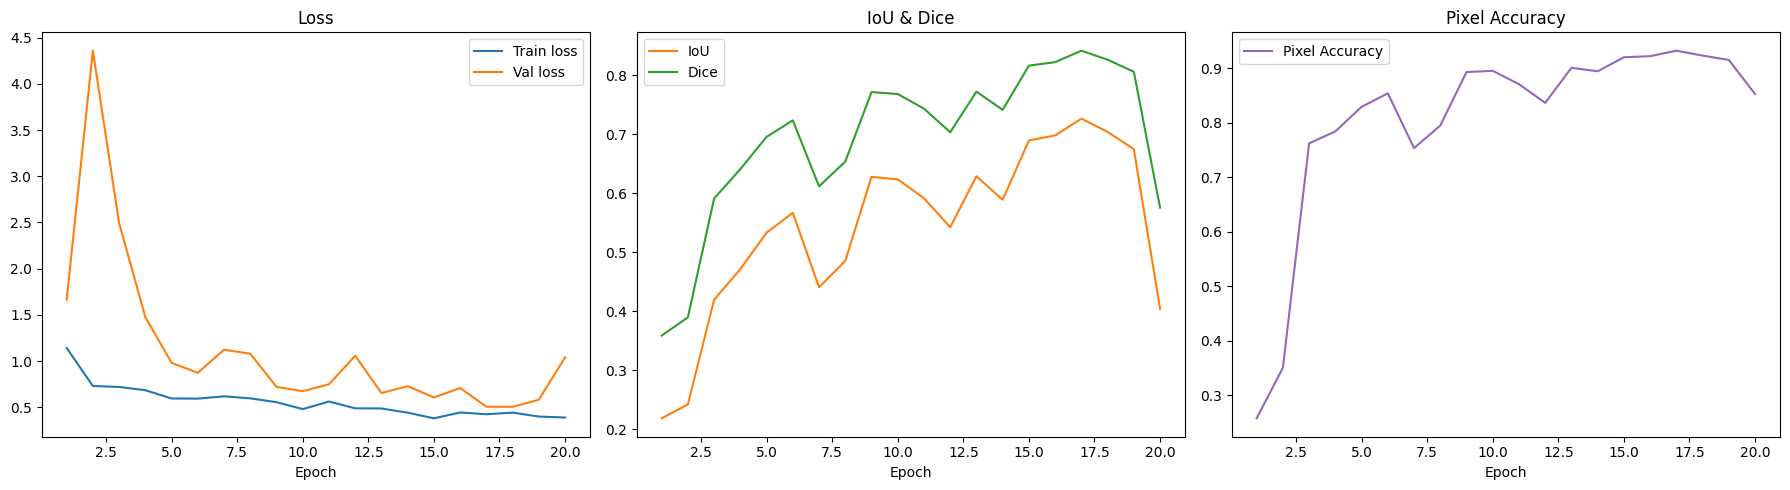

Courbes sauvegardées : training_curves.png


In [ ]:
########################################
# COURBES D'ENTRAÎNEMENT
########################################

epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, train_losses, label="Train loss")
axes[0].plot(epochs_range, val_losses, label="Val loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_range, iou_scores_hist, label="IoU", color="tab:orange")
axes[1].plot(epochs_range, dice_scores_hist, label="Dice", color="tab:green")
axes[1].set_title("IoU & Dice")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(epochs_range, acc_scores_hist, label="Pixel Accuracy", color="tab:purple")
axes[2].set_title("Pixel Accuracy")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Courbes sauvegardées : training_curves.png")

In [ ]:
########################################
# ÉVALUATION COMPLÈTE SUR LE TEST SET
########################################

# Charger le meilleur modèle
model.load_state_dict(torch.load("best_unet.pth", map_location=device))
model.eval()

test_iou = test_dice = test_acc = test_prec = test_rec = 0.0

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Test evaluation"):
        images, masks = images.to(device), masks.to(device)
        with autocast_ctx():
            preds = model(images)

        test_iou  += iou_score(preds, masks).item()
        test_dice += dice_score(preds, masks).item()
        test_acc  += pixel_accuracy(preds, masks).item()
        test_prec += precision_score(preds, masks).item()
        test_rec  += recall_score(preds, masks).item()

n = len(test_loader)
print("\n===== TEST SET RESULTS =====")
print(f"  IoU       : {test_iou/n:.4f}")
print(f"  Dice      : {test_dice/n:.4f}")
print(f"  Pixel Acc : {test_acc/n:.4f}")
print(f"  Precision : {test_prec/n:.4f}")
print(f"  Recall    : {test_rec/n:.4f}")

Test evaluation: 100%|██████████| 17/17 [00:14<00:00,  1.15it/s]


===== TEST SET RESULTS =====
  IoU       : 0.5418
  Dice      : 0.6862
  Pixel Acc : 0.8504
  Precision : 0.7596
  Recall    : 0.6853


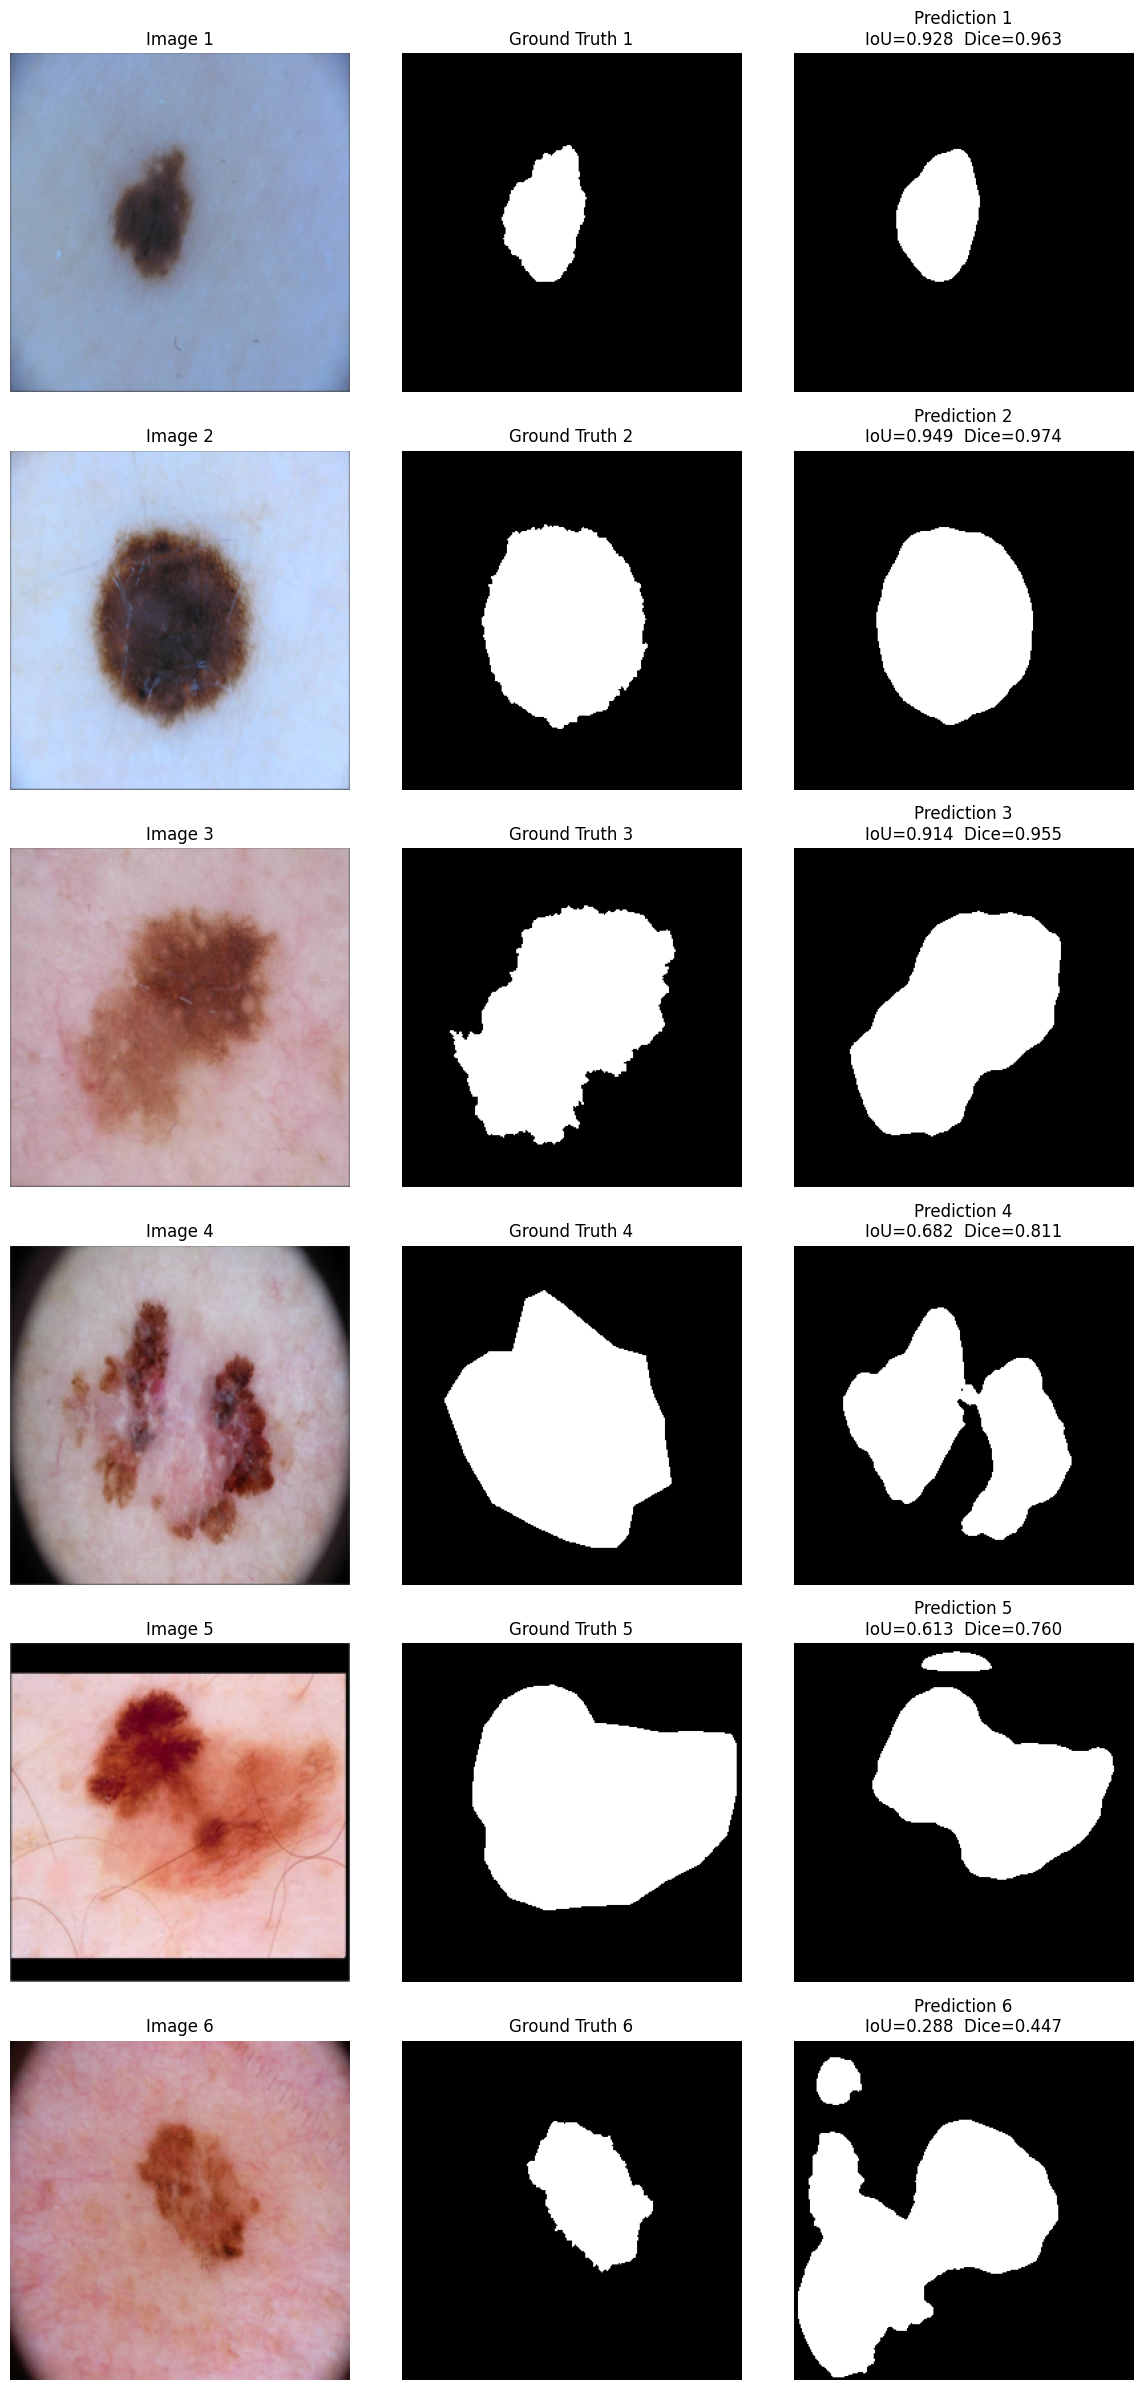

Prédictions sauvegardées : predictions.png


In [ ]:
########################################
# VISUALISATION QUALITATIVE (6 exemples)
########################################

def denormalize(tensor, mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)):
    t = tensor.clone()
    for c, m, s in zip(t, mean, std):
        c.mul_(s).add_(m)
    return t.clamp(0, 1)

num_samples = 6
fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 4))

for i in range(num_samples):
    image, mask = test_dataset[i]
    image_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(image_tensor)

    pred_bin = binarize(pred).squeeze().cpu()
    image_display = denormalize(image).permute(1, 2, 0).cpu()

    iou_val  = iou_score(pred.cpu(), mask.unsqueeze(0)).item()
    dice_val = dice_score(pred.cpu(), mask.unsqueeze(0)).item()

    axes[i, 0].imshow(image_display)
    axes[i, 0].set_title(f"Image {i+1}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask.squeeze(), cmap="gray")
    axes[i, 1].set_title(f"Ground Truth {i+1}")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(pred_bin, cmap="gray")
    axes[i, 2].set_title(f"Prediction {i+1}\nIoU={iou_val:.3f}  Dice={dice_val:.3f}")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig("predictions.png", dpi=150)
plt.show()
print("Prédictions sauvegardées : predictions.png")
